In [2]:
%load_ext autoreload
%reload_ext autoreload

%autoreload 2
%matplotlib inline
import math
import tensorflow
from tensorflow.compat.v1.keras.backend import get_session
tensorflow.compat.v1.disable_v2_behavior()
import kerasAC 
from kerasAC.generators.snp_generator import *
from kerasAC.tiledb_config import *
from scipy.special import softmax
from kerasAC.interpret.deepshap import * 
from kerasAC.interpret.profile_shap import * 
from kerasAC.vis import * 
from kerasAC.helpers.transform_bpnet_io import * 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import pyBigWig 
pbw=pyBigWig.open("/oak/stanford/groups/akundaje/projects/atlas/dnase_processed/dnase/13da5ebe-0941-4855-8599-40bbcc5c58b4/call-bowtie2/shard-0/execution/ENCSR000EMT.merged.bam.bpnet.unstranded.bw",'r')

In [9]:
#make sure the snp coordinate is 0-based
import pandas as pd 
snps=pd.read_csv("/srv/scratch/annashch/chrombpnet/gm12878_dnase/bQTL/stat1.txt",header=0,sep='\t')
snps['Pos0']=snps['position']-1
snps['rsid']=snps['Chr'].astype(str)+'_'+snps['Pos0'].astype(str)+'_'+snps['POSTallele'].astype(str)+'_'+snps['ALTallele'].astype('str')
snps.to_csv("stat1.formatted.csv",header=True,index=False,sep='\t')
snps.head() 

,Chr,position,Depth,ALTdepth,REFDepth,ALTallele,POSTallele,POSTfreq,prechipfreq,pvalue,Pos0,rsid
0,chr6,26660655,23,0,23,C,G,1.000000,0.053600,5.898792e-30,26660654,chr6_26660654_G_C
1,chr7,100230864,41,4,37,C,G,0.902439,0.135022,3.851247e-28,100230863,chr7_100230863_G_C
2,chr7,12727826,20,18,2,C,G,0.100000,0.935861,5.655764e-20,12727825,chr7_12727825_G_C
3,chr7,303680,27,23,4,G,A,0.148148,0.880638,6.327731e-18,303679,chr7_303679_A_G
4,chr1,145209819,47,25,22,T,C,0.468085,0.929858,4.512281e-17,145209818,chr1_145209818_C_T


In [10]:
#reference allele sequence generator 
ref_gen=SNPGenerator(bed_path="stat1.formatted.csv",
                 chrom_col="Chr",
                 pos_col="Pos0",
                 allele_col="POSTallele",
                 rsid_col='rsid',
                 flank_size=673,
                 ref_fasta="/mnt/data/male.hg19.fa",
                 expand_dims=False)

#alternate allele sequence generator 
alt_gen=SNPGenerator(bed_path="stat1.formatted.csv",
                 chrom_col="Chr",
                 pos_col="Pos0",
                 allele_col="ALTallele",
                 rsid_col='rsid',
                 flank_size=673,
                 ref_fasta="/mnt/data/male.hg19.fa",
                 expand_dims=False)


In [11]:
#load the model! 
from keras.models import load_model
from keras.utils.generic_utils import get_custom_objects
from kerasAC.metrics import * 
from kerasAC.custom_losses import * 
custom_objects={"recall":recall,
                    "sensitivity":recall,
                    "specificity":specificity,
                    "fpr":fpr,
                    "fnr":fnr,
                    "precision":precision,
                    "f1":f1,
                    "ambig_binary_crossentropy":ambig_binary_crossentropy,
                    "ambig_mean_absolute_error":ambig_mean_absolute_error,
                    "ambig_mean_squared_error":ambig_mean_squared_error,
                    "MultichannelMultinomialNLL":MultichannelMultinomialNLL}
get_custom_objects().update(custom_objects)
model=load_model("/srv/scratch/annashch/chrombpnet/gm12878_dnase/with_bias_bpnet_tobias/gm12878.dnase.with.bpnet.tobias.bias.0.hdf5")

In [12]:
#get the reference allele predictions 
count_preds={} 
profile_preds={} 
snp_to_seq={} 
for i in range(len(ref_gen)):
    print(str(i))
    cur_x=ref_gen[i] 
    batch_rsids=cur_x[0] 
    batch_preds=model.predict(cur_x[1])
    batch_preds_profile=batch_preds[0]
    batch_preds_count=batch_preds[1] 
    for batch_index in range(len(batch_rsids)): 
        cur_rsid=batch_rsids[batch_index]
        snp_to_seq[cur_rsid]={} 
        snp_to_seq[cur_rsid]['ref']=cur_x[1][batch_index,:,:]
        cur_pred_profile=batch_preds_profile[batch_index,:,:]
        cur_pred_count=batch_preds_count[batch_index,:][0]
        count_preds[cur_rsid]={}
        count_preds[cur_rsid]['ref']=cur_pred_count
        profile_preds[cur_rsid]={}
        profile_preds[cur_rsid]['ref']=cur_pred_profile 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [13]:
#get the alternate allele predictions 
for i in range(len(alt_gen)):
    print(str(i))
    cur_x=alt_gen[i] 
    batch_rsids=cur_x[0] 
    batch_preds=model.predict(cur_x[1])
    batch_preds_profile=batch_preds[0]
    batch_preds_count=batch_preds[1] 
    for batch_index in range(len(batch_rsids)): 
        cur_rsid=batch_rsids[batch_index]
        snp_to_seq[cur_rsid]['alt']=cur_x[1][batch_index,:,:]
        cur_pred_profile=batch_preds_profile[batch_index,:,:]
        cur_pred_count=batch_preds_count[batch_index,:][0]
        count_preds[cur_rsid]['alt']=cur_pred_count
        profile_preds[cur_rsid]['alt']=cur_pred_profile 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [14]:
#convert dictionary to pandas df for easier manipulation 
count_preds_df=pd.DataFrame.from_dict(count_preds,orient='index')
count_preds_df['Alt_Minus_Ref']=count_preds_df['alt']-count_preds_df['ref']
#sort by difference 
count_preds_df=count_preds_df.sort_values(by=["Alt_Minus_Ref"])
count_preds_df.to_csv("stat1_count_predictions_alt_and_ref.tsv",header=True,index=True,sep='\t')

print(count_preds_df.head())
print(count_preds_df.tail())

                         ref       alt  Alt_Minus_Ref
chr10_5894499_A_G   6.893589  6.212861      -0.680728
chr14_90348414_C_T  6.147260  5.509457      -0.637804
chr18_10213741_T_G  6.278359  5.646066      -0.632294
chr12_47802215_A_G  6.247313  5.648417      -0.598897
chr3_48264788_C_G   6.537132  5.940541      -0.596591
                         ref       alt  Alt_Minus_Ref
chr9_36659724_T_C   5.442578  5.993062       0.550484
chr20_15966016_C_G  6.105165  6.681021       0.575856
chr3_42531938_G_A   6.042291  6.623177       0.580886
chr15_70174408_C_T  5.793444  6.399358       0.605914
chr17_53495972_C_T  5.584737  6.244070       0.659333


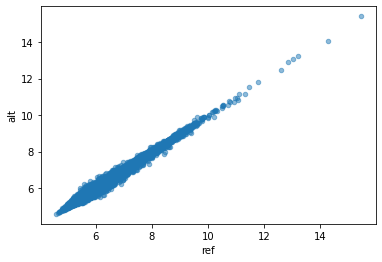

In [15]:
#scatter ref vs alt log(count) pred 
count_preds_df.plot.scatter(x='ref',y='alt',alpha=0.5)

In [21]:
from scipy.special import softmax,logit,softmax
from scipy.spatial.distance import jensenshannon



In [23]:
#get the JSD for profile preds 
jsd_dict={} 
for rsid in profile_preds: 
    ref_preds=softmax(profile_preds[rsid]['ref'],axis=0)
    alt_preds=softmax(profile_preds[rsid]['alt'],axis=0)
    cur_jsd=jensenshannon(ref_preds,alt_preds)
    jsd_dict[rsid]=cur_jsd
    

In [24]:
jsd_df=pd.DataFrame.from_dict(jsd_dict,orient='index')


In [26]:
jsd_df.head()
#sort by difference 
jsd_df=jsd_df.sort_values(by=[0])
jsd_df.to_csv("stat1_jsd_predictions.tsv",header=True,index=True,sep='\t')

print(jsd_df.head())
print(jsd_df.tail())

                           0
chr20_5654596_G_C   0.001386
chr19_17419847_T_C  0.001700
chr17_37607903_C_T  0.001726
chr1_203307484_C_T  0.001729
chr17_72788097_A_C  0.001764
                           0
chr10_99436608_A_C  0.293857
chr14_24527671_G_A  0.304522
chr7_143187993_G_C  0.313102
chr6_25223878_C_T   0.349692
chr8_11137204_G_C   0.352627


In [38]:
jsd_df['JSD']=jsd_df[0]
jsd_df=jsd_df.drop(columns=[0])

In [39]:
#merge the data frames
merged=pd.merge(jsd_df,count_preds_df,left_index=True,right_index=True)
merged=pd.merge(merged,snps,left_index=True,right_on=['rsid'])

In [40]:
merged['-log10P']=-1*np.log10(merged['pvalue'])

In [41]:
merged.head()

,JSD,ref,alt,Alt_Minus_Ref,Chr,position,Depth,ALTdepth,REFDepth,ALTallele,POSTallele,POSTfreq,prechipfreq,pvalue,Pos0,rsid,-log10P
136714,0.001386,6.314472,6.310136,-0.004336,chr20,5654597,18,2,16,C,G,0.888889,0.806687,0.553838,5654596,chr20_5654596_G_C,0.256617
333233,0.001700,7.801745,7.811666,0.009921,chr19,17419848,17,4,13,C,T,0.764706,0.781411,1.000000,17419847,chr19_17419847_T_C,-0.000000
76521,0.001726,7.865357,7.845406,-0.019951,chr17,37607904,37,11,26,T,C,0.702703,0.778677,0.319905,37607903,chr17_37607903_C_T,0.494980
266910,0.001729,5.745135,5.729712,-0.015424,chr1,203307485,16,1,15,T,C,0.937500,0.967699,1.000000,203307484,chr1_203307484_C_T,-0.000000
152225,0.001764,5.734522,5.736480,0.001958,chr17,72788098,19,2,17,C,A,0.894737,0.942601,0.623678,72788097,chr17_72788097_A_C,0.205040


In [51]:
min(merged['Alt_Minus_Ref'])

-0.6807284355163574

In [48]:
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower

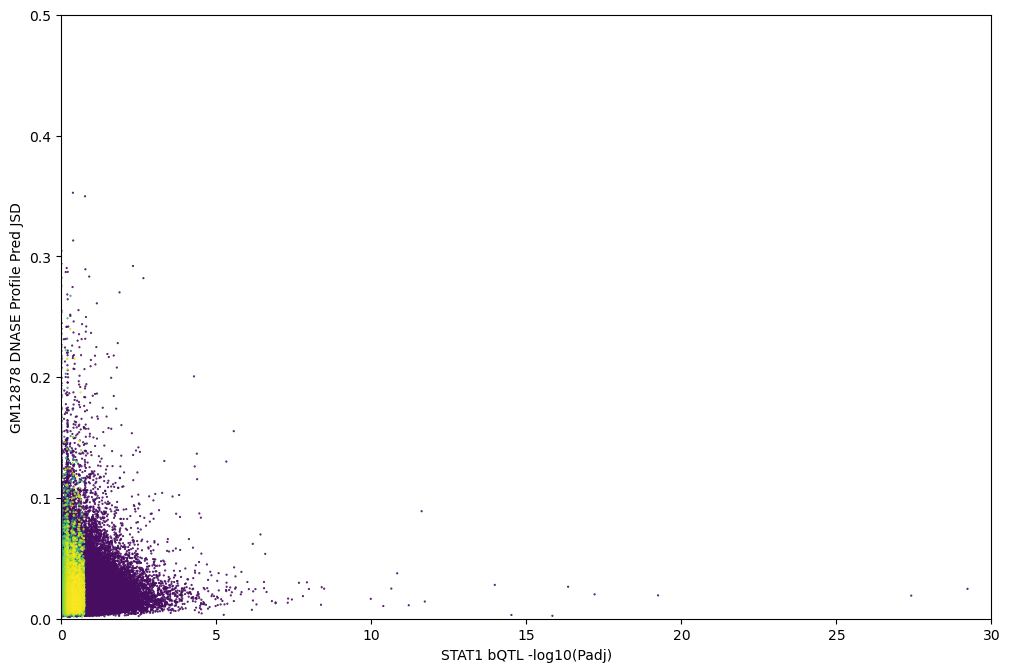

In [49]:
#plot the distribution of p-value vs JSD & p-value vs delta counts 
from kerasAC.vis.density_scatter import * 
density_scatter(merged['-log10P'],merged['JSD'],xlab='STAT1 bQTL -log10(Padj)',ylab='GM12878 DNASE Profile Pred JSD',xlim=(0,30),ylim=(0,0.5))

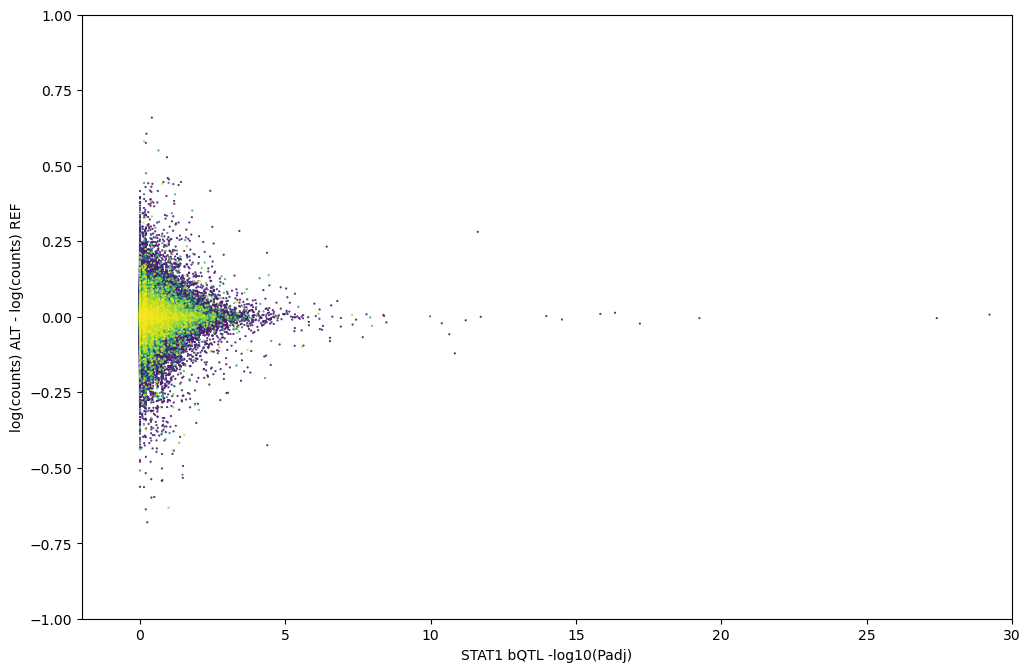

In [54]:
density_scatter(merged['-log10P'],merged['Alt_Minus_Ref'],xlab='STAT1 bQTL -log10(Padj)',ylab='log(counts) ALT - log(counts) REF',xlim=(-2,30),ylim=(-1,1))

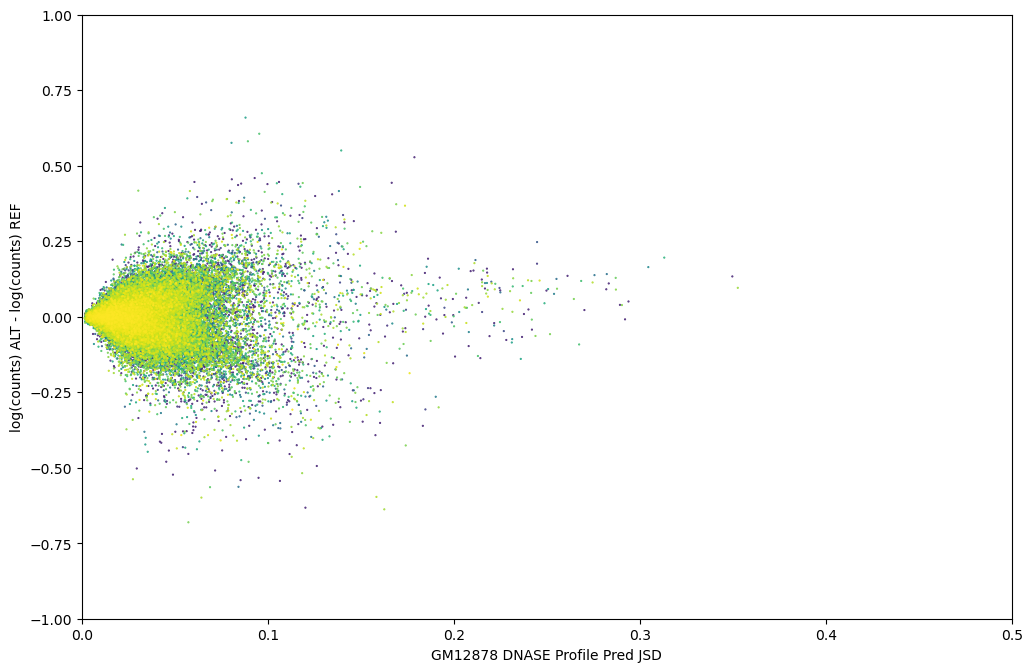

In [55]:
density_scatter(merged['JSD'],merged['Alt_Minus_Ref'],xlab='GM12878 DNASE Profile Pred JSD',ylab='log(counts) ALT - log(counts) REF',xlim=(0,0.5),ylim=(-1,1))

In [109]:
#get shap values for the SNPs with the highest delta 

#create the explainers 
task_index=0
model_wrapper_for_counts=(model.input, model.outputs[1][:,task_index:task_index+1])
create_background_counts=create_background_atac
#model_wrapper=(model.input, model.layers[-1].output)
count_explainer=shap.DeepExplainer(model_wrapper,data=create_background_counts,combine_mult_and_diffref=combine_mult_and_diffref_1d)
prof_explainer = create_explainer(model,ischip=False,task_index=task_index)

In [110]:
## for plotting 
%load_ext autoreload
%reload_ext autoreload

%autoreload 2
%matplotlib inline
import matplotlib 
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"]=10,5
plt.rcParams['axes.xmargin'] = 0

font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 10}

matplotlib.rc('font', **font)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [111]:
def make_plot(rsid,
              count_pred_ref,
              count_pred_alt,
              pred_prob_ref,
              pred_prob_alt,
              profile_explanations_ref, 
              seq_ref,
              profile_explanations_alt,
              seq_alt,
              count_explanations_ref, 
              count_explanations_alt,
              xmin=0,
              xmax=1000,
              ymin_shap=-0.1,
              ymin_perf=-0.1,
              ymax_shap=0.1,
              ymax_perf=0.1):
    plt.rcParams["figure.figsize"]=20,10
    fig, axes = plt.subplots(5, 1)
    axes[0].plot(pred_prob_ref,label='Ref Prob',color='b')
    axes[0].plot(pred_prob_alt,label='Alt Prob',color='r')
    axes[0].set_title(str(rsid)+"Counts Pred Ref:"+str(count_pred_ref)+":"+"Counts Pred Alt:"+str(count_pred_alt))
    axes[0].legend() 
    axes[0].set_xlim(xmin,xmax)
    axes[0].set_ylim(ymin_perf,ymax_perf)
    axes[0].set_xticks(list(range(xmin, xmax, 50,)))    
    
    axes[1]=plot_seq_importance(profile_explanations_ref,seq_ref,xlim=(xmin,xmax),axes=axes[1])
    axes[1].set_title("Profile Loss SHAP, Ref")        
    axes[1].set_ylim(ymin_shap,ymax_shap)
    axes[1].set_xticks(list(range(xmin, xmax, 50,)))    

    axes[2]=plot_seq_importance(profile_explanations_alt,seq_alt,xlim=(xmin,xmax),axes=axes[2])
    axes[2].set_title("Profile Loss SHAP, Alt")        
    axes[2].set_ylim(ymin_shap,ymax_shap)
    axes[2].set_xticks(list(range(xmin, xmax, 50,)))    
    
    
    axes[3]=plot_seq_importance(count_explanations_ref,seq_ref,xlim=(xmin,xmax),axes=axes[3])
    axes[3].set_title("Count Loss SHAP, Ref")        
    axes[3].set_ylim(ymin_shap,ymax_shap)
    axes[3].set_xticks(list(range(xmin, xmax, 50,)))    

    axes[4]=plot_seq_importance(count_explanations_alt,seq_alt,xlim=(xmin,xmax),axes=axes[4])
    axes[4].set_title("Count Loss SHAP, Alt")        
    axes[4].set_ylim(ymin_shap,ymax_shap)
    axes[4].set_xticks(list(range(xmin, xmax, 50,))) 

    plt.subplots_adjust(hspace=0.6)
    plt.show()

In [112]:
merged=merged.sort_values(by=["JSD"])

merged.tail()

,JSD,ref,alt,Alt_Minus_Ref,Chr,position,Depth,ALTdepth,REFDepth,ALTallele,POSTallele,POSTfreq,prechipfreq,pvalue,Pos0,rsid,-log10P
330429,0.293857,5.480697,5.531158,0.050461,chr10,99436609,29,1,28,C,A,0.965517,0.958536,1.000000,99436608,chr10_99436608_A_C,-0.000000
286882,0.304522,5.332016,5.496282,0.164266,chr14,24527672,48,1,47,A,G,0.979167,0.971396,1.000000,24527671,chr14_24527671_G_A,-0.000000
107339,0.313102,5.115118,5.310870,0.195752,chr7,143187994,23,2,21,C,G,0.913043,0.843008,0.416826,143187993,chr7_143187993_G_C,0.380046
42939,0.349692,5.545726,5.679164,0.133438,chr6,25223879,45,0,45,T,C,1.000000,0.952103,0.172865,25223878,chr6_25223878_C_T,0.762292
111273,0.352627,5.364349,5.460070,0.095720,chr8,11137205,47,0,47,C,G,1.000000,0.976468,0.425147,11137204,chr8_11137204_G_C,0.371460


In [113]:

rsid="chr8_11137204_G_C"
chrom='chr8'
curpos=11137204

cur_seq_ref=np.expand_dims(snp_to_seq[rsid]['ref'],axis=0)
cur_seq_alt=np.expand_dims(snp_to_seq[rsid]['alt'],axis=0)
count_pred_ref=count_preds[rsid]['ref']
count_pred_alt=count_preds[rsid]['alt']
pred_prob_ref=softmax(profile_preds[rsid]['ref'],axis=0)
pred_prob_alt=softmax(profile_preds[rsid]['alt'],axis=0)
profile_explanations_ref=prof_explainer(cur_seq_ref,None)
count_explanations_ref=np.squeeze(count_explainer.shap_values(cur_seq_ref)[0])
profile_explanations_alt=prof_explainer(cur_seq_alt,None)
count_explanations_alt=np.squeeze(count_explainer.shap_values(cur_seq_alt)[0])


In [117]:
prof_explainer(cur_seq_ref,None).max()

0.0

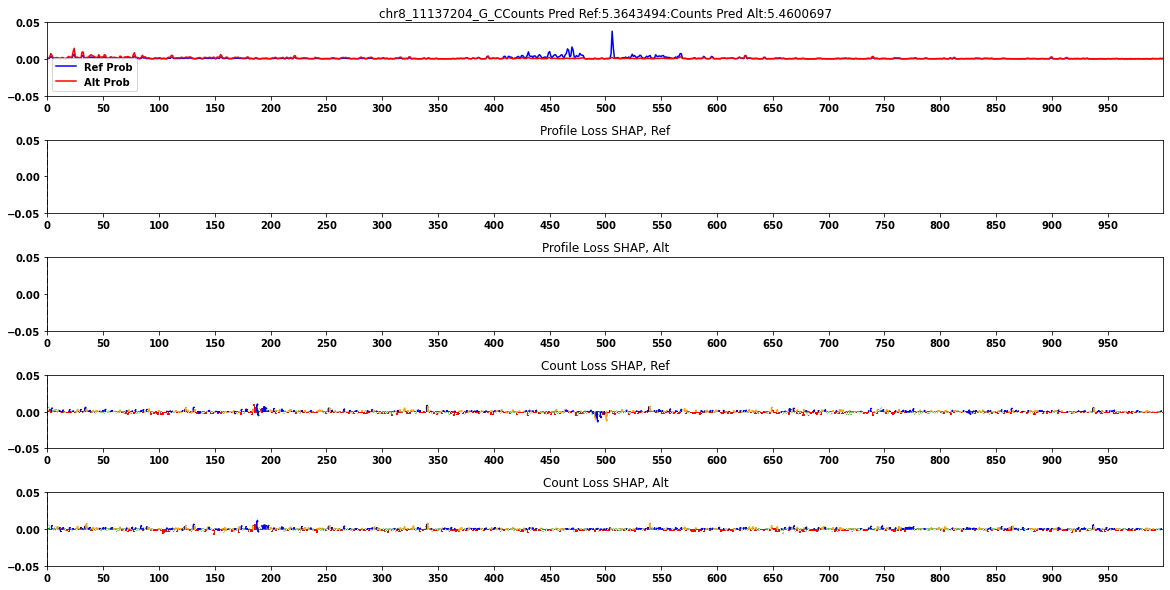

In [107]:
make_plot(rsid,
          count_pred_ref,
          count_pred_alt,
          pred_prob_ref,
          pred_prob_alt,
          profile_explanations_ref[:,173:173+1000,:],
          cur_seq_ref[:,173:173+1000,:],
          profile_explanations_alt[:,173:173+1000,:],
          cur_seq_alt[:,173:173+1000,:],
          count_explanations_ref[173:173+1000,:],
          count_explanations_alt[173:173+1000,:],
          xmin=0,
          xmax=1000,
          ymin_shap=-0.05,
          ymin_perf=-0.05,
          ymax_shap=0.05,
          ymax_perf=0.05)

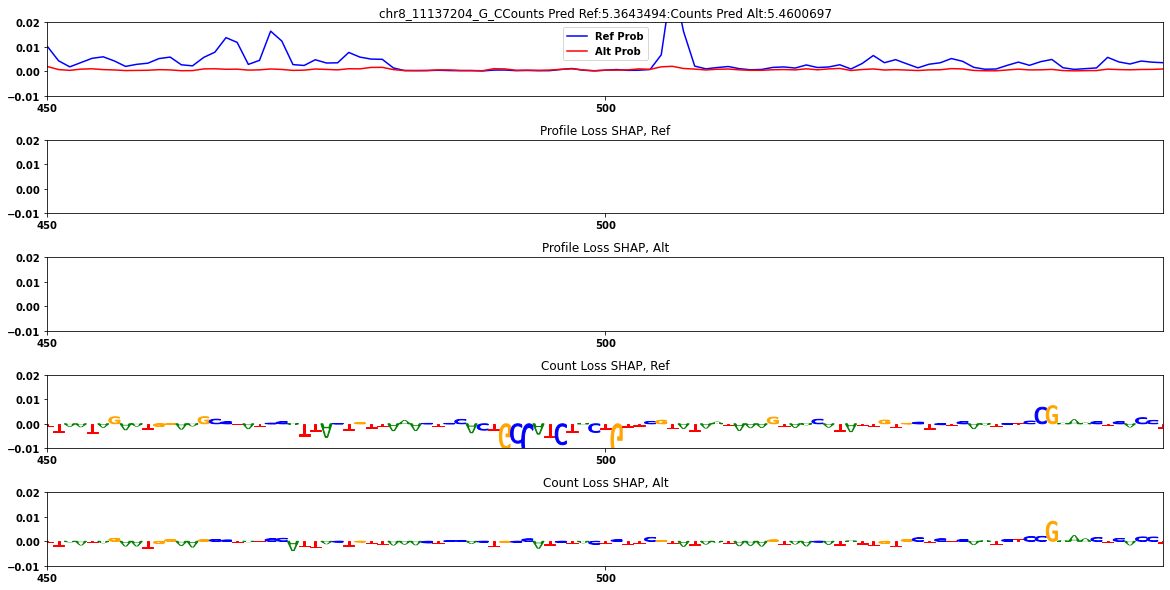

In [108]:
make_plot(rsid,
          count_pred_ref,
          count_pred_alt,
          pred_prob_ref,
          pred_prob_alt,
          profile_explanations_ref[:,173:173+1000,:],
          cur_seq_ref[:,173:173+1000,:],
          profile_explanations_alt[:,173:173+1000,:],
          cur_seq_alt[:,173:173+1000,:],
          count_explanations_ref[173:173+1000,:],
          count_explanations_alt[173:173+1000,:],
          xmin=450,
          xmax=550,
          ymin_shap=-0.01,
          ymin_perf=-0.01,
          ymax_shap=0.02,
          ymax_perf=0.02)